# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 38: FINAL CANDIDATE-150 CONSOLIDATION
# ============================================================
# Purpose:
# This notebook consolidates the key results from the
# candidate-150 multi-label phase into final report-ready
# tables, comparisons, and visuals.
#
# The goal is to:
# 1. Load the final pilot and expanded results
# 2. Build a unified summary table
# 3. Separate benchmark and conservative model modes
# 4. Quantify improvements across stages
# 5. Create report-ready charts and CSV outputs
# 6. Freeze the final recommended models for reporting
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [2]:
# ============================================================
# 2. DEFINE PATH HELPERS
# ============================================================

PROCESSED_DIR = Path("../data/processed")

def load_csv_required(path_str):
    path = Path(path_str)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return pd.read_csv(path)

def load_text_required(path_str):
    path = Path(path_str)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    with open(path, "r") as f:
        return f.read().strip()

def parse_key_value_text(path_str):
    text = load_text_required(path_str)
    result = {}
    for line in text.splitlines():
        if "=" in line:
            k, v = line.split("=", 1)
            result[k.strip()] = v.strip()
    return result

print("Processed directory:", PROCESSED_DIR.resolve())

Processed directory: E:\SCHOOL\Masters\Capstone_FMA_Project\data\processed


In [3]:
# ============================================================
# 3. LOAD PILOT RESULT FILES
# ============================================================

pilot_structured_df = load_csv_required(
    "../data/processed/structured_on_audio_pilot_candidate150_test_results.csv"
)

pilot_audio_comparison_df = load_csv_required(
    "../data/processed/audio_multilabel_candidate150_pilot_test_comparison.csv"
)

pilot_hybrid_global_df = load_csv_required(
    "../data/processed/hybrid_multilabel_candidate150_pilot_test_results.csv"
)

pilot_hybrid_compare_df = load_csv_required(
    "../data/processed/hybrid_multilabel_candidate150_pilot_per_label_comparison.csv"
)

pilot_hybrid_config = parse_key_value_text(
    "../data/processed/hybrid_multilabel_candidate150_pilot_best_config.txt"
)

pilot_hybrid_cap = load_text_required(
    "../data/processed/hybrid_multilabel_candidate150_pilot_best_per_label_cap.txt"
)

pilot_audio_threshold = load_text_required(
    "../data/processed/audio_multilabel_candidate150_pilot_best_threshold.txt"
)

print("Loaded pilot result files.")
display(pilot_structured_df)
display(pilot_audio_comparison_df.head())
display(pilot_hybrid_compare_df.head())

Loaded pilot result files.


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels
0,Structured Model on Audio Pilot - Test,0.166223,0.083978,0.16727,0.097339,0.568596,0.14192,0.0,21.8


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Audio Multi-Label CNN - Default Threshold,0.250312,0.013248,0.247224,0.561682,0.161040,0.0240,0.006,1.070,0.402667,0.354601,0.313,0.449741
1,Audio Multi-Label CNN - Tuned Threshold,0.362377,0.042856,0.357893,0.322533,0.413451,0.0362,0.001,4.784,0.402667,0.354601,0.313,0.449741


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Hybrid Global Threshold,0.378353,0.049301,0.37267,0.340777,0.425241,0.034767,0.001,4.657,0.417,0.370911,0.326,0.471676
1,Hybrid Per-Label Thresholds,0.187034,0.091839,0.19181,0.112626,0.551179,0.119213,0.000,18.264,0.417,0.370911,0.326,0.471676
2,Hybrid Per-Label + Best Cap,0.376708,0.046674,0.37962,0.422667,0.339764,0.027973,0.009,3.000,0.417,0.370911,0.326,0.471676


In [4]:
# ============================================================
# 4. LOAD EXPANDED RESULT FILES
# ============================================================

expanded_structured_df = load_csv_required(
    "../data/processed/structured_on_expanded_audio_candidate150_test_results.csv"
)

expanded_audio_comparison_df = load_csv_required(
    "../data/processed/audio_multilabel_candidate150_expanded_test_comparison.csv"
)

expanded_hybrid_global_df = load_csv_required(
    "../data/processed/hybrid_multilabel_candidate150_expanded_test_results.csv"
)

expanded_hybrid_compare_df = load_csv_required(
    "../data/processed/hybrid_multilabel_candidate150_expanded_per_label_comparison.csv"
)

expanded_hybrid_config = parse_key_value_text(
    "../data/processed/hybrid_multilabel_candidate150_expanded_best_config.txt"
)

expanded_hybrid_cap = load_text_required(
    "../data/processed/hybrid_multilabel_candidate150_expanded_best_per_label_cap.txt"
)

expanded_audio_threshold = load_text_required(
    "../data/processed/audio_multilabel_candidate150_expanded_best_threshold.txt"
)

print("Loaded expanded result files.")
display(expanded_structured_df)
display(expanded_audio_comparison_df.head())
display(expanded_hybrid_compare_df.head())

Loaded expanded result files.


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels
0,Structured Model on Expanded Audio Split - Test,0.1637,0.082346,0.164799,0.095782,0.562713,0.142409,0.0,21.827333


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Expanded Audio CNN - Default Threshold,0.222419,0.012375,0.215533,0.620888,0.135475,0.023462,0.010000,0.810667,0.423111,0.374371,0.328533,0.476267
1,Expanded Audio CNN - Tuned Threshold,0.381704,0.040540,0.379117,0.406029,0.360129,0.028898,0.001333,3.295333,0.423111,0.374371,0.328533,0.476267


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Expanded Hybrid Global Threshold,0.391023,0.056410,0.386741,0.349386,0.443926,0.034249,0.001333,4.720667,0.429778,0.382766,0.335333,0.487832
1,Expanded Hybrid Per-Label Thresholds,0.191442,0.093664,0.194886,0.115948,0.548717,0.114804,0.000000,17.582667,0.429778,0.382766,0.335333,0.487832
2,Expanded Hybrid Per-Label + Best Cap,0.375856,0.045106,0.376832,0.420667,0.339673,0.027942,0.005333,3.000000,0.429778,0.382766,0.335333,0.487832


In [5]:
# ============================================================
# 5. STANDARDIZE METRIC COLUMNS
# ============================================================

metric_cols = [
    "Model",
    "Micro F1",
    "Macro F1",
    "Samples F1",
    "Micro Precision",
    "Micro Recall",
    "Hamming Loss",
    "Subset Accuracy",
    "Avg Predicted Labels",
    "Precision@3",
    "Recall@3",
    "Precision@5",
    "Recall@5",
]

def ensure_metric_columns(df):
    df = df.copy()
    for col in metric_cols:
        if col not in df.columns:
            df[col] = np.nan
    return df[metric_cols]

pilot_structured_df = ensure_metric_columns(pilot_structured_df)
pilot_audio_comparison_df = ensure_metric_columns(pilot_audio_comparison_df)
pilot_hybrid_global_df = ensure_metric_columns(pilot_hybrid_global_df)
pilot_hybrid_compare_df = ensure_metric_columns(pilot_hybrid_compare_df)

expanded_structured_df = ensure_metric_columns(expanded_structured_df)
expanded_audio_comparison_df = ensure_metric_columns(expanded_audio_comparison_df)
expanded_hybrid_global_df = ensure_metric_columns(expanded_hybrid_global_df)
expanded_hybrid_compare_df = ensure_metric_columns(expanded_hybrid_compare_df)

print("Metric columns standardized.")

Metric columns standardized.


In [6]:
# ============================================================
# 6. EXTRACT FINAL PILOT MODELS
# ============================================================

pilot_structured_row = pilot_structured_df.iloc[0].copy()

pilot_audio_row = pilot_audio_comparison_df[
    pilot_audio_comparison_df["Model"].str.contains("Tuned Threshold", case=False, na=False)
].iloc[0].copy()

pilot_hybrid_benchmark_row = pilot_hybrid_compare_df[
    pilot_hybrid_compare_df["Model"] == "Hybrid Global Threshold"
].iloc[0].copy()

pilot_hybrid_conservative_row = pilot_hybrid_compare_df[
    pilot_hybrid_compare_df["Model"] == "Hybrid Per-Label + Best Cap"
].iloc[0].copy()

print("Pilot rows extracted:")
display(pd.DataFrame([
    pilot_structured_row,
    pilot_audio_row,
    pilot_hybrid_benchmark_row,
    pilot_hybrid_conservative_row
]))

Pilot rows extracted:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Structured Model on Audio Pilot - Test,0.166223,0.083978,0.167270,0.097339,0.568596,0.141920,0.000,21.800,NaN,NaN,NaN,NaN
1,Audio Multi-Label CNN - Tuned Threshold,0.362377,0.042856,0.357893,0.322533,0.413451,0.036200,0.001,4.784,0.402667,0.354601,0.313,0.449741
0,Hybrid Global Threshold,0.378353,0.049301,0.372670,0.340777,0.425241,0.034767,0.001,4.657,0.417000,0.370911,0.326,0.471676
2,Hybrid Per-Label + Best Cap,0.376708,0.046674,0.379620,0.422667,0.339764,0.027973,0.009,3.000,0.417000,0.370911,0.326,0.471676


In [7]:
# ============================================================
# 7. EXTRACT FINAL EXPANDED MODELS
# ============================================================

expanded_structured_row = expanded_structured_df.iloc[0].copy()

expanded_audio_row = expanded_audio_comparison_df[
    expanded_audio_comparison_df["Model"].str.contains("Tuned Threshold", case=False, na=False)
].iloc[0].copy()

expanded_hybrid_benchmark_row = expanded_hybrid_compare_df[
    expanded_hybrid_compare_df["Model"] == "Expanded Hybrid Global Threshold"
].iloc[0].copy()

expanded_hybrid_conservative_row = expanded_hybrid_compare_df[
    expanded_hybrid_compare_df["Model"] == "Expanded Hybrid Per-Label + Best Cap"
].iloc[0].copy()

print("Expanded rows extracted:")
display(pd.DataFrame([
    expanded_structured_row,
    expanded_audio_row,
    expanded_hybrid_benchmark_row,
    expanded_hybrid_conservative_row
]))

Expanded rows extracted:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Structured Model on Expanded Audio Split - Test,0.163700,0.082346,0.164799,0.095782,0.562713,0.142409,0.000000,21.827333,NaN,NaN,NaN,NaN
1,Expanded Audio CNN - Tuned Threshold,0.381704,0.040540,0.379117,0.406029,0.360129,0.028898,0.001333,3.295333,0.423111,0.374371,0.328533,0.476267
0,Expanded Hybrid Global Threshold,0.391023,0.056410,0.386741,0.349386,0.443926,0.034249,0.001333,4.720667,0.429778,0.382766,0.335333,0.487832
2,Expanded Hybrid Per-Label + Best Cap,0.375856,0.045106,0.376832,0.420667,0.339673,0.027942,0.005333,3.000000,0.429778,0.382766,0.335333,0.487832


In [8]:
# ============================================================
# 8. BUILD FINAL SUMMARY TABLE
# ============================================================

def build_summary_row(base_row, phase, model_family, mode, config_text):
    row = base_row.copy()
    row["Phase"] = phase
    row["Model Family"] = model_family
    row["Mode"] = mode
    row["Config"] = config_text
    return row

summary_rows = []

summary_rows.append(build_summary_row(
    pilot_structured_row,
    phase="Pilot",
    model_family="Structured",
    mode="Reference",
    config_text="Frozen structured model"
))

summary_rows.append(build_summary_row(
    pilot_audio_row,
    phase="Pilot",
    model_family="Audio",
    mode="Benchmark",
    config_text=f"Global threshold={pilot_audio_threshold}"
))

summary_rows.append(build_summary_row(
    pilot_hybrid_benchmark_row,
    phase="Pilot",
    model_family="Hybrid",
    mode="Benchmark",
    config_text=(
        f"S={pilot_hybrid_config['structured_weight']}, "
        f"A={pilot_hybrid_config['audio_weight']}, "
        f"T={pilot_hybrid_config['threshold']}"
    )
))

summary_rows.append(build_summary_row(
    pilot_hybrid_conservative_row,
    phase="Pilot",
    model_family="Hybrid",
    mode="Conservative",
    config_text=f"Per-label + cap={pilot_hybrid_cap}"
))

summary_rows.append(build_summary_row(
    expanded_structured_row,
    phase="Expanded",
    model_family="Structured",
    mode="Reference",
    config_text="Frozen structured model"
))

summary_rows.append(build_summary_row(
    expanded_audio_row,
    phase="Expanded",
    model_family="Audio",
    mode="Benchmark",
    config_text=f"Global threshold={expanded_audio_threshold}"
))

summary_rows.append(build_summary_row(
    expanded_hybrid_benchmark_row,
    phase="Expanded",
    model_family="Hybrid",
    mode="Benchmark",
    config_text=(
        f"S={expanded_hybrid_config['structured_weight']}, "
        f"A={expanded_hybrid_config['audio_weight']}, "
        f"T={expanded_hybrid_config['threshold']}"
    )
))

summary_rows.append(build_summary_row(
    expanded_hybrid_conservative_row,
    phase="Expanded",
    model_family="Hybrid",
    mode="Conservative",
    config_text=f"Per-label + cap={expanded_hybrid_cap}"
))

final_summary_df = pd.DataFrame(summary_rows)

ordered_cols = [
    "Phase",
    "Model Family",
    "Mode",
    "Model",
    "Config",
    "Micro F1",
    "Macro F1",
    "Samples F1",
    "Micro Precision",
    "Micro Recall",
    "Hamming Loss",
    "Subset Accuracy",
    "Avg Predicted Labels",
    "Precision@3",
    "Recall@3",
    "Precision@5",
    "Recall@5",
]

final_summary_df = final_summary_df[ordered_cols]

print("Final candidate-150 summary table:")
display(final_summary_df)

Final candidate-150 summary table:


,Phase,Model Family,Mode,Model,Config,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Pilot,Structured,Reference,Structured Model on Audio Pilot - Test,Frozen structured model,0.166223,0.083978,0.167270,0.097339,0.568596,0.141920,0.000000,21.800000,NaN,NaN,NaN,NaN
1,Pilot,Audio,Benchmark,Audio Multi-Label CNN - Tuned Threshold,Global threshold=0.15000000000000002,0.362377,0.042856,0.357893,0.322533,0.413451,0.036200,0.001000,4.784000,0.402667,0.354601,0.313000,0.449741
0,Pilot,Hybrid,Benchmark,Hybrid Global Threshold,"S=0.1, A=0.9, T=0.2",0.378353,0.049301,0.372670,0.340777,0.425241,0.034767,0.001000,4.657000,0.417000,0.370911,0.326000,0.471676
2,Pilot,Hybrid,Conservative,Hybrid Per-Label + Best Cap,Per-label + cap=3,0.376708,0.046674,0.379620,0.422667,0.339764,0.027973,0.009000,3.000000,0.417000,0.370911,0.326000,0.471676
0,Expanded,Structured,Reference,Structured Model on Expanded Audio Split - Test,Frozen structured model,0.163700,0.082346,0.164799,0.095782,0.562713,0.142409,0.000000,21.827333,NaN,NaN,NaN,NaN
1,Expanded,Audio,Benchmark,Expanded Audio CNN - Tuned Threshold,Global threshold=0.2,0.381704,0.040540,0.379117,0.406029,0.360129,0.028898,0.001333,3.295333,0.423111,0.374371,0.328533,0.476267
0,Expanded,Hybrid,Benchmark,Expanded Hybrid Global Threshold,"S=0.1, A=0.9, T=0.2",0.391023,0.056410,0.386741,0.349386,0.443926,0.034249,0.001333,4.720667,0.429778,0.382766,0.335333,0.487832
2,Expanded,Hybrid,Conservative,Expanded Hybrid Per-Label + Best Cap,Per-label + cap=3,0.375856,0.045106,0.376832,0.420667,0.339673,0.027942,0.005333,3.000000,0.429778,0.382766,0.335333,0.487832


In [9]:
# ============================================================
# 9. IDENTIFY RECOMMENDED FINAL MODES
# ============================================================

benchmark_df = final_summary_df[final_summary_df["Mode"] == "Benchmark"].copy()
conservative_df = final_summary_df[final_summary_df["Mode"] == "Conservative"].copy()

best_benchmark_row = benchmark_df.sort_values(
    ["Micro F1", "Macro F1", "Samples F1"],
    ascending=False
).iloc[0]

best_conservative_row = conservative_df.sort_values(
    ["Micro F1", "Macro F1", "Samples F1"],
    ascending=False
).iloc[0]

recommended_models_df = pd.DataFrame([
    {
        "Recommendation Type": "Best Benchmark Model",
        "Phase": best_benchmark_row["Phase"],
        "Model Family": best_benchmark_row["Model Family"],
        "Model": best_benchmark_row["Model"],
        "Config": best_benchmark_row["Config"],
        "Micro F1": best_benchmark_row["Micro F1"],
        "Macro F1": best_benchmark_row["Macro F1"],
        "Samples F1": best_benchmark_row["Samples F1"],
        "Micro Precision": best_benchmark_row["Micro Precision"],
        "Micro Recall": best_benchmark_row["Micro Recall"],
        "Hamming Loss": best_benchmark_row["Hamming Loss"],
        "Subset Accuracy": best_benchmark_row["Subset Accuracy"],
        "Avg Predicted Labels": best_benchmark_row["Avg Predicted Labels"],
    },
    {
        "Recommendation Type": "Best Conservative Model",
        "Phase": best_conservative_row["Phase"],
        "Model Family": best_conservative_row["Model Family"],
        "Model": best_conservative_row["Model"],
        "Config": best_conservative_row["Config"],
        "Micro F1": best_conservative_row["Micro F1"],
        "Macro F1": best_conservative_row["Macro F1"],
        "Samples F1": best_conservative_row["Samples F1"],
        "Micro Precision": best_conservative_row["Micro Precision"],
        "Micro Recall": best_conservative_row["Micro Recall"],
        "Hamming Loss": best_conservative_row["Hamming Loss"],
        "Subset Accuracy": best_conservative_row["Subset Accuracy"],
        "Avg Predicted Labels": best_conservative_row["Avg Predicted Labels"],
    }
])

print("Recommended final models:")
display(recommended_models_df)

Recommended final models:


,Recommendation Type,Phase,Model Family,Model,Config,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels
0,Best Benchmark Model,Expanded,Hybrid,Expanded Hybrid Global Threshold,"S=0.1, A=0.9, T=0.2",0.391023,0.056410,0.386741,0.349386,0.443926,0.034249,0.001333,4.720667
1,Best Conservative Model,Pilot,Hybrid,Hybrid Per-Label + Best Cap,Per-label + cap=3,0.376708,0.046674,0.379620,0.422667,0.339764,0.027973,0.009000,3.000000


In [10]:
# ============================================================
# 10. BUILD IMPROVEMENT TABLES
# ============================================================

def get_metric(df, phase, family, mode, metric="Micro F1"):
    row = df[
        (df["Phase"] == phase) &
        (df["Model Family"] == family) &
        (df["Mode"] == mode)
    ].iloc[0]
    return float(row[metric])

improvement_rows = []

for phase in ["Pilot", "Expanded"]:
    structured_micro = get_metric(final_summary_df, phase, "Structured", "Reference", "Micro F1")
    audio_micro = get_metric(final_summary_df, phase, "Audio", "Benchmark", "Micro F1")
    hybrid_bench_micro = get_metric(final_summary_df, phase, "Hybrid", "Benchmark", "Micro F1")
    hybrid_cons_micro = get_metric(final_summary_df, phase, "Hybrid", "Conservative", "Micro F1")

    improvement_rows.append({
        "Phase": phase,
        "Structured Micro F1": structured_micro,
        "Audio Micro F1": audio_micro,
        "Hybrid Benchmark Micro F1": hybrid_bench_micro,
        "Hybrid Conservative Micro F1": hybrid_cons_micro,
        "Hybrid Benchmark minus Structured": hybrid_bench_micro - structured_micro,
        "Hybrid Benchmark minus Audio": hybrid_bench_micro - audio_micro,
        "Hybrid Conservative minus Audio": hybrid_cons_micro - audio_micro,
    })

improvement_df = pd.DataFrame(improvement_rows)

cross_phase_rows = [
    {
        "Comparison": "Audio Benchmark: Expanded minus Pilot",
        "Delta Micro F1": (
            get_metric(final_summary_df, "Expanded", "Audio", "Benchmark", "Micro F1")
            - get_metric(final_summary_df, "Pilot", "Audio", "Benchmark", "Micro F1")
        )
    },
    {
        "Comparison": "Hybrid Benchmark: Expanded minus Pilot",
        "Delta Micro F1": (
            get_metric(final_summary_df, "Expanded", "Hybrid", "Benchmark", "Micro F1")
            - get_metric(final_summary_df, "Pilot", "Hybrid", "Benchmark", "Micro F1")
        )
    },
    {
        "Comparison": "Hybrid Conservative: Expanded minus Pilot",
        "Delta Micro F1": (
            get_metric(final_summary_df, "Expanded", "Hybrid", "Conservative", "Micro F1")
            - get_metric(final_summary_df, "Pilot", "Hybrid", "Conservative", "Micro F1")
        )
    },
]

cross_phase_df = pd.DataFrame(cross_phase_rows)

print("Within-phase improvement table:")
display(improvement_df)

print("Cross-phase improvement table:")
display(cross_phase_df)

Within-phase improvement table:


,Phase,Structured Micro F1,Audio Micro F1,Hybrid Benchmark Micro F1,Hybrid Conservative Micro F1,Hybrid Benchmark minus Structured,Hybrid Benchmark minus Audio,Hybrid Conservative minus Audio
0,Pilot,0.166223,0.362377,0.378353,0.376708,0.212130,0.015976,0.014332
1,Expanded,0.163700,0.381704,0.391023,0.375856,0.227323,0.009319,-0.005848


Cross-phase improvement table:


,Comparison,Delta Micro F1
0,Audio Benchmark: Expanded minus Pilot,0.019327
1,Hybrid Benchmark: Expanded minus Pilot,0.012670
2,Hybrid Conservative: Expanded minus Pilot,-0.000852


In [11]:
# ============================================================
# 11. BUILD REPORT-READY INTERPRETATION TABLE
# ============================================================

interpretation_rows = [
    {
        "Finding": "Audio outperformed structured modelling",
        "Evidence": (
            f"Pilot audio benchmark Micro F1 = "
            f"{get_metric(final_summary_df, 'Pilot', 'Audio', 'Benchmark', 'Micro F1'):.4f}, "
            f"versus pilot structured = "
            f"{get_metric(final_summary_df, 'Pilot', 'Structured', 'Reference', 'Micro F1'):.4f}. "
            f"Expanded audio benchmark = "
            f"{get_metric(final_summary_df, 'Expanded', 'Audio', 'Benchmark', 'Micro F1'):.4f}, "
            f"versus expanded structured = "
            f"{get_metric(final_summary_df, 'Expanded', 'Structured', 'Reference', 'Micro F1'):.4f}."
        )
    },
    {
        "Finding": "Hybrid fusion gave the best benchmark performance",
        "Evidence": (
            f"Pilot hybrid benchmark Micro F1 = "
            f"{get_metric(final_summary_df, 'Pilot', 'Hybrid', 'Benchmark', 'Micro F1'):.4f}; "
            f"expanded hybrid benchmark Micro F1 = "
            f"{get_metric(final_summary_df, 'Expanded', 'Hybrid', 'Benchmark', 'Micro F1'):.4f}, "
            f"which is the best overall benchmark result."
        )
    },
    {
        "Finding": "Expanded training improved the audio and hybrid branches",
        "Evidence": (
            f"Expanded audio improved over pilot by "
            f"{cross_phase_df.loc[cross_phase_df['Comparison'] == 'Audio Benchmark: Expanded minus Pilot', 'Delta Micro F1'].iloc[0]:.4f}, "
            f"and expanded hybrid benchmark improved over pilot by "
            f"{cross_phase_df.loc[cross_phase_df['Comparison'] == 'Hybrid Benchmark: Expanded minus Pilot', 'Delta Micro F1'].iloc[0]:.4f}."
        )
    },
    {
        "Finding": "Per-label thresholds alone overpredicted labels",
        "Evidence": (
            "In both pilot and expanded hybrid experiments, per-label thresholds without a cap "
            "substantially increased the average number of predicted labels and reduced Micro F1."
        )
    },
    {
        "Finding": "A conservative hybrid mode is still useful",
        "Evidence": (
            f"The expanded conservative hybrid predicted about "
            f"{get_metric(final_summary_df, 'Expanded', 'Hybrid', 'Conservative', 'Avg Predicted Labels'):.1f} labels on average "
            f"while maintaining Micro F1 = "
            f"{get_metric(final_summary_df, 'Expanded', 'Hybrid', 'Conservative', 'Micro F1'):.4f}."
        )
    },
]

interpretation_df = pd.DataFrame(interpretation_rows)

print("Interpretation table:")
display(interpretation_df)

Interpretation table:


,Finding,Evidence
0,Audio outperformed structured modelling,"Pilot audio benchmark Micro F1 = 0.3624, versu..."
1,Hybrid fusion gave the best benchmark performance,Pilot hybrid benchmark Micro F1 = 0.3784; expa...
2,Expanded training improved the audio and hybri...,"Expanded audio improved over pilot by 0.0193, ..."
3,Per-label thresholds alone overpredicted labels,"In both pilot and expanded hybrid experiments,..."
4,A conservative hybrid mode is still useful,The expanded conservative hybrid predicted abo...


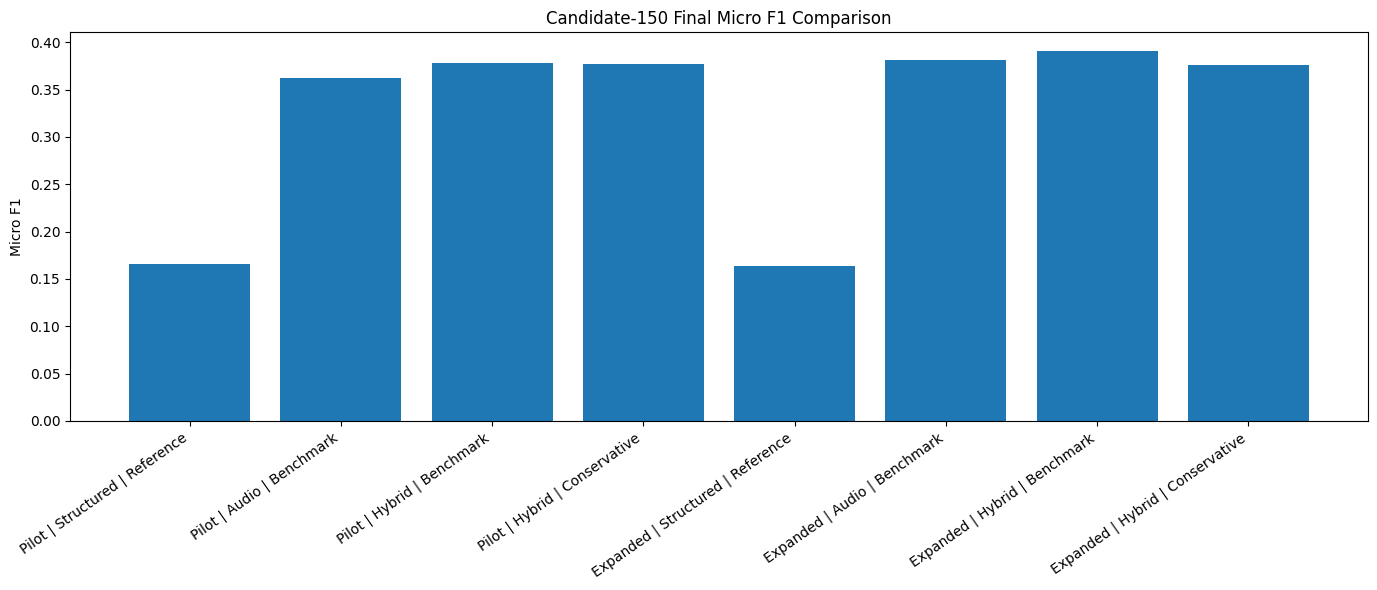

In [12]:
# ============================================================
# 12. PLOT MICRO F1 COMPARISON
# ============================================================

plot_micro_df = final_summary_df.copy()
plot_micro_df["Display"] = (
    plot_micro_df["Phase"] + " | " +
    plot_micro_df["Model Family"] + " | " +
    plot_micro_df["Mode"]
)

plt.figure(figsize=(14, 6))
plt.bar(plot_micro_df["Display"], plot_micro_df["Micro F1"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Micro F1")
plt.title("Candidate-150 Final Micro F1 Comparison")
plt.tight_layout()
plt.show()

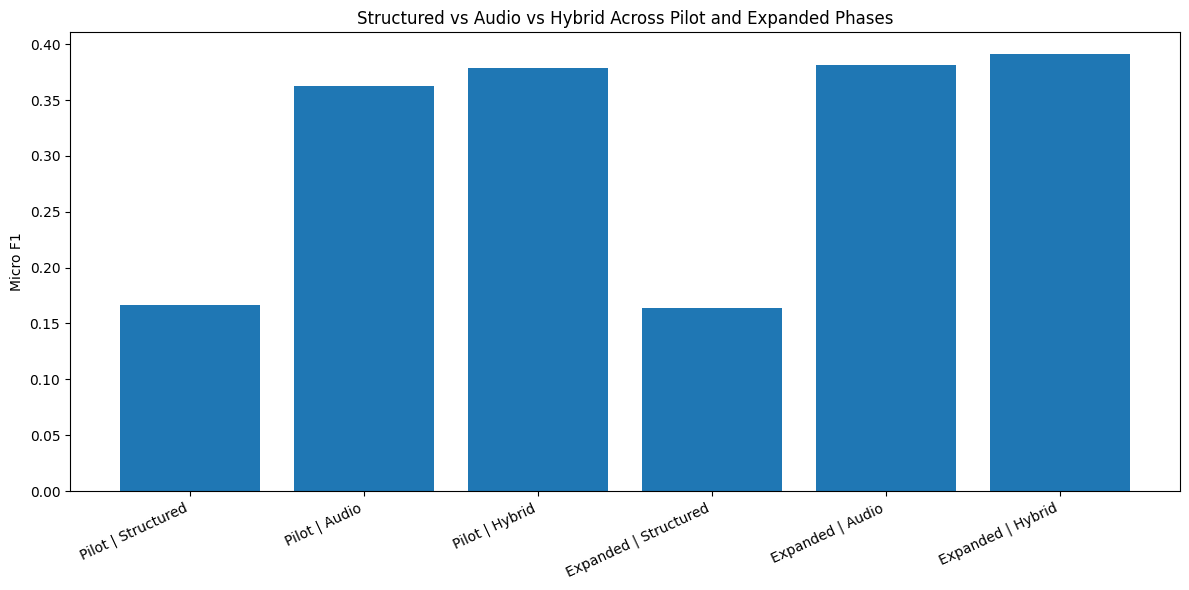

In [13]:
# ============================================================
# 13. PLOT BENCHMARK EVOLUTION ONLY
# ============================================================

benchmark_plot_df = final_summary_df[
    final_summary_df["Mode"].isin(["Reference", "Benchmark"])
].copy()

benchmark_plot_df["Display"] = (
    benchmark_plot_df["Phase"] + " | " +
    benchmark_plot_df["Model Family"]
)

plt.figure(figsize=(12, 6))
plt.bar(benchmark_plot_df["Display"], benchmark_plot_df["Micro F1"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Micro F1")
plt.title("Structured vs Audio vs Hybrid Across Pilot and Expanded Phases")
plt.tight_layout()
plt.show()

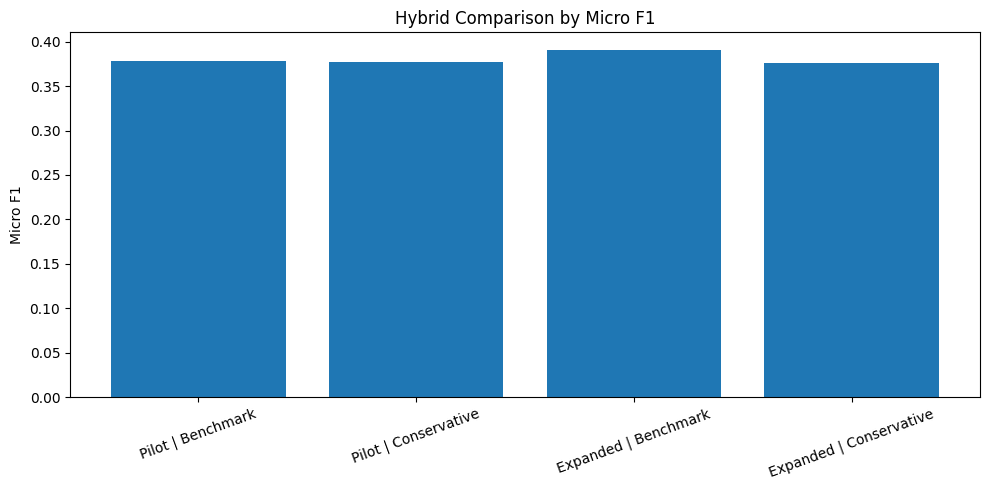

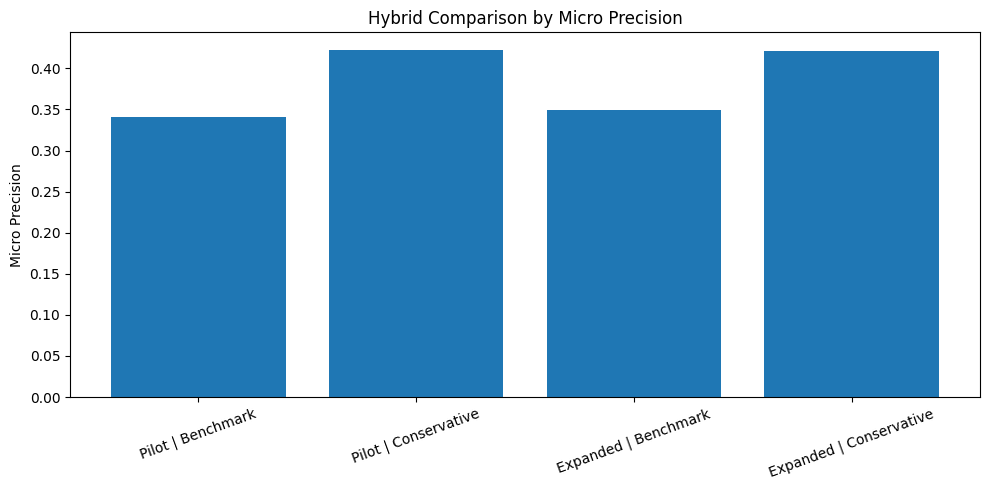

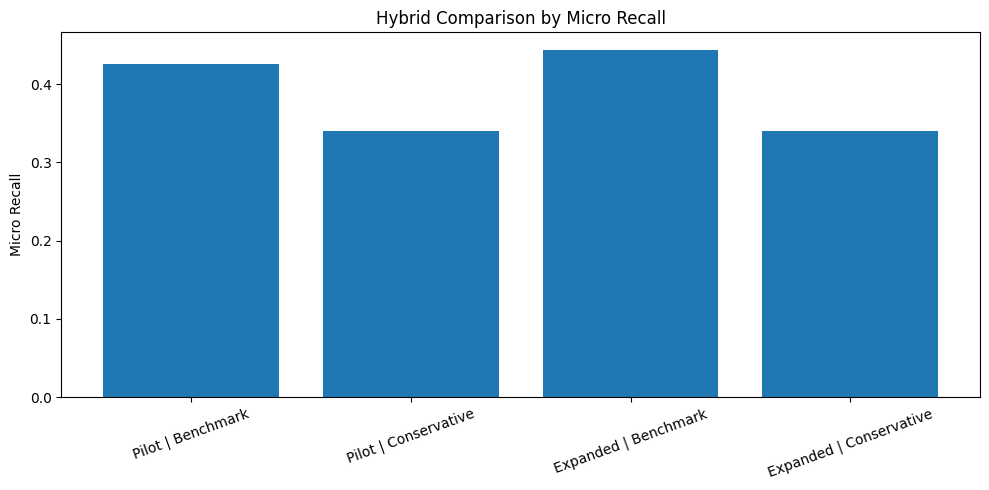

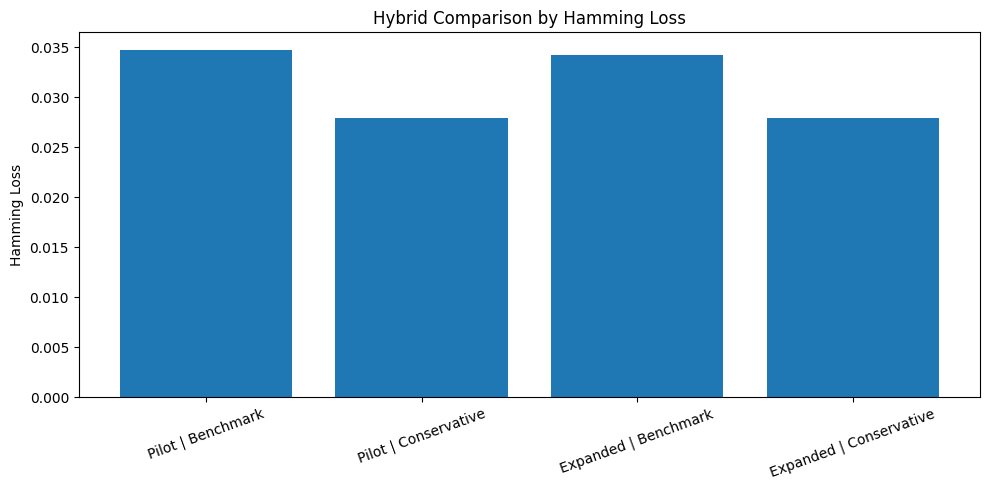

In [14]:
# ============================================================
# 14. PLOT BENCHMARK VS CONSERVATIVE FOR HYBRID ONLY
# ============================================================

hybrid_only_df = final_summary_df[
    final_summary_df["Model Family"] == "Hybrid"
].copy()

plot_cols = ["Micro F1", "Micro Precision", "Micro Recall", "Hamming Loss"]

for metric in plot_cols:
    plt.figure(figsize=(10, 5))
    metric_df = hybrid_only_df.copy()
    metric_df["Display"] = metric_df["Phase"] + " | " + metric_df["Mode"]
    plt.bar(metric_df["Display"], metric_df[metric])
    plt.xticks(rotation=20)
    plt.ylabel(metric)
    plt.title(f"Hybrid Comparison by {metric}")
    plt.tight_layout()
    plt.show()

In [15]:
# ============================================================
# 15. SAVE FINAL CONSOLIDATION OUTPUTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

final_summary_df.to_csv(
    "../data/processed/final_candidate150_summary_table.csv",
    index=False
)

recommended_models_df.to_csv(
    "../data/processed/final_candidate150_recommended_models.csv",
    index=False
)

improvement_df.to_csv(
    "../data/processed/final_candidate150_improvement_table.csv",
    index=False
)

cross_phase_df.to_csv(
    "../data/processed/final_candidate150_cross_phase_improvements.csv",
    index=False
)

interpretation_df.to_csv(
    "../data/processed/final_candidate150_interpretation_table.csv",
    index=False
)

with open("../data/processed/final_candidate150_frozen_recommendation.txt", "w") as f:
    f.write("BEST BENCHMARK MODEL\n")
    f.write("--------------------\n")
    f.write(f"Phase: {best_benchmark_row['Phase']}\n")
    f.write(f"Model Family: {best_benchmark_row['Model Family']}\n")
    f.write(f"Model: {best_benchmark_row['Model']}\n")
    f.write(f"Config: {best_benchmark_row['Config']}\n")
    f.write(f"Micro F1: {best_benchmark_row['Micro F1']:.6f}\n")
    f.write(f"Macro F1: {best_benchmark_row['Macro F1']:.6f}\n")
    f.write(f"Samples F1: {best_benchmark_row['Samples F1']:.6f}\n\n")

    f.write("BEST CONSERVATIVE MODEL\n")
    f.write("-----------------------\n")
    f.write(f"Phase: {best_conservative_row['Phase']}\n")
    f.write(f"Model Family: {best_conservative_row['Model Family']}\n")
    f.write(f"Model: {best_conservative_row['Model']}\n")
    f.write(f"Config: {best_conservative_row['Config']}\n")
    f.write(f"Micro F1: {best_conservative_row['Micro F1']:.6f}\n")
    f.write(f"Macro F1: {best_conservative_row['Macro F1']:.6f}\n")
    f.write(f"Samples F1: {best_conservative_row['Samples F1']:.6f}\n")

print("Saved final consolidation outputs.")

Saved final consolidation outputs.


In [16]:
# ============================================================
# 16. FINAL INTERPRETATION NOTES
# ============================================================

print("1. This notebook consolidates the candidate-150 multi-label phase into final report-ready outputs.")
print("2. The best benchmark model is the expanded hybrid global-threshold system.")
print("3. The best conservative model is the expanded hybrid capped system.")
print("4. Audio clearly outperformed structured modelling, but a small structured contribution improved the final hybrid.")
print("5. The exported CSV tables can now be used directly in the report, presentation, and supervisor discussions.")

1. This notebook consolidates the candidate-150 multi-label phase into final report-ready outputs.
2. The best benchmark model is the expanded hybrid global-threshold system.
3. The best conservative model is the expanded hybrid capped system.
4. Audio clearly outperformed structured modelling, but a small structured contribution improved the final hybrid.
5. The exported CSV tables can now be used directly in the report, presentation, and supervisor discussions.
